# DS2000 & DS2001 Programming with Data & Practicum

# Lab 11: Regression

Welcome to Lab 11!

In today's lab, we will get some hands-on practice with linear regression. 

Reading:

* [Chap 15.2 The Regression Line](https://www.inferentialthinking.com/chapters/15/2/Regression_Line.html#the-regression-line).

First, set up the notebook by running the cell below.

In [1]:
# Run this cell, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

import otter
grader = otter.Notebook("lab11.ipynb")

# 1. How Faithful is Old Faithful? 

Old Faithful is a geyser in Yellowstone National Park that is famous for eruption on a fairly regular schedule. Run the cell below to see Old Faithful in action!

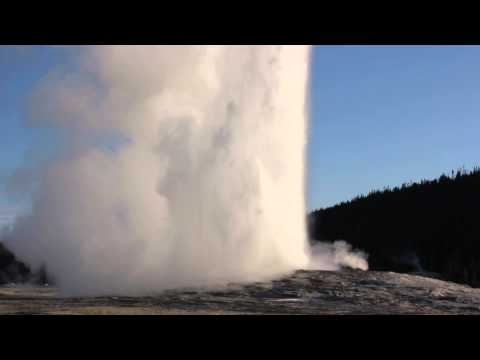

In [2]:
# For the curious: this is how to display a YouTube video in a
# Jupyter notebook.  The argument to YouTubeVideo is the part
# of the URL (called a "query parameter") that identifies the
# video.  For example, the full URL for this video is:
#   https://www.youtube.com/watch?v=wE8NDuzt8eg
from IPython.display import YouTubeVideo
YouTubeVideo("wE8NDuzt8eg")

Some of Old Faithful's eruptions last longer than others.  Whenever there is a long eruption, it is usually followed by an even longer wait before the next eruption. If you visit Yellowstone, you might want to predict when the next eruption will happen, so that you can see the rest of the park instead of waiting by the geyser.
 
Today, we will use a dataset on eruption durations and waiting times to see if we can make such predictions accurately with linear regression.

The dataset has one row for each observed eruption.  It includes the following columns:
- `duration`: Eruption duration, in minutes
- `wait`: Time between this eruption and the next, also in minutes

Run the next cell to load the dataset.

In [3]:
faithful = Table.read_table("faithful.csv")
faithful

duration,wait
3.6,79
1.8,54
3.333,74
2.283,62
4.533,85
2.883,55
4.7,88
3.6,85
1.95,51
4.35,85


**Question 1.1.** The following statements are the unordered steps of linear regression.

1. Compute the parameters of the regression line: the slope and the intercept.
2. Evaluate the regression line by computing the line’s RMSE and analyzing the residuals plot.
3. Use the regression line to generate predictions for each x value.
4. Determine if linear regression is a reasonable method by visualizing your data and computing the correlation coefficient.

Make an array called least_squares_order that contains the correct order of a linear regression analysis, where the first item of the array is the first step of an linear regression analysis and the last item of the array is the last step of an linear regression analysis.

In [4]:
least_squares_order = make_array(4,1,3,2)

In [5]:
grader.check("q1_1")

q1_1 results: All test cases passed!

We would like to use linear regression to make predictions, but that won't work well if the data aren't roughly linearly related.  To check that, we should look at the data.

**Question 1.2.** Make a scatter plot of the data.  It's conventional to put the column we want to **predict** on the **vertical axis** and the other column on the horizontal axis.


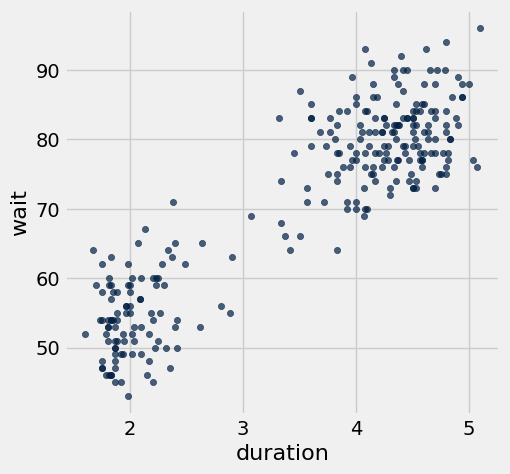

In [6]:
faithful.scatter("duration", "wait")

**Question 1.3.** Are eruption duration and waiting time roughly linearly related based on the scatter plot above? Is this relationship positive?

Yes, the eruption duration and wait time appear to be roughly linearly related, with a positive association.

We're going to continue with the assumption that they are linearly related, so it's reasonable to use linear regression to analyze this data.

We'd next like to plot the data in standard units. If you don't remember the definition of standard units, textbook section [14.2](https://www.inferentialthinking.com/chapters/14/2/Variability.html#standard-units) might help!

**Question 1.4.** Compute the mean and standard deviation of the eruption durations and waiting times.  **Then** create a table called `faithful_standard` containing the eruption durations and waiting times in standard units.  The columns should be named `duration (standard units)` and `wait (standard units)`.

In [7]:
duration_mean = np.average(faithful.column("duration"))
duration_std = np.std(faithful.column("duration"))
wait_mean = np.average(faithful.column("wait"))
wait_std = np.std(faithful.column("wait"))

faithful_standard = Table().with_columns(
    "duration (standard units)", (faithful.column("duration")-duration_mean
                                 )/(duration_std),
    "wait (standard units)", (faithful.column("wait")-wait_mean)/(wait_std))
faithful_standard

duration (standard units),wait (standard units)
0.0984989,0.597123
-1.48146,-1.24518
-0.135861,0.228663
-1.0575,-0.655644
0.917443,1.03928
-0.530851,-1.17149
1.06403,1.26035
0.0984989,1.03928
-1.3498,-1.46626
0.756814,1.03928


In [8]:
grader.check("q1_4")

q1_4 results: All test cases passed!

**Question 1.5.** Plot the data again, but this time in standard units.

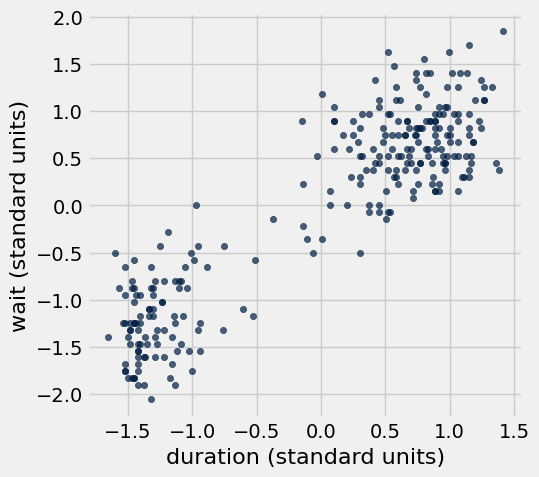

In [9]:
faithful_standard.scatter("duration (standard units)",
                          "wait (standard units)")

You'll notice that this plot looks the same as the last one!  However, the data and axes are scaled differently.  So it's important to read the ticks on the axes.

**Question 1.6.** Among the following numbers, which would you guess is closest to the correlation between eruption duration and waiting time in this dataset?

1. -1
2. 0
3. 1

Assign `correlation` to the number corresponding to your guess (either 1, 2 or 3).

In [10]:
correlation = 3

In [11]:
grader.check("q1_6")

q1_6 results: All test cases passed!

**Question 1.7.** Compute the correlation coefficient `r`.  

*Hint:* Use `faithful_standard`.  Section [15.1](https://www.inferentialthinking.com/chapters/15/1/Correlation.html#calculating-r) explains how to do this.

In [12]:
r = np.average(faithful_standard.column(
    "duration (standard units)") * faithful_standard.column(
    "wait (standard units)"))
r

0.90081116832181318

In [13]:
grader.check("q1_7")

q1_7 results: All test cases passed!

# 2. The Regression Line
Recall that the **correlation** is the **slope of the regression line when the data are put in standard units**.

The next cell plots the regression line in standard units:

$$\text{waiting time in standard units} = r \times \text{eruption duration in standard units}$$

Then, it plots the data in standard units again, for comparison.

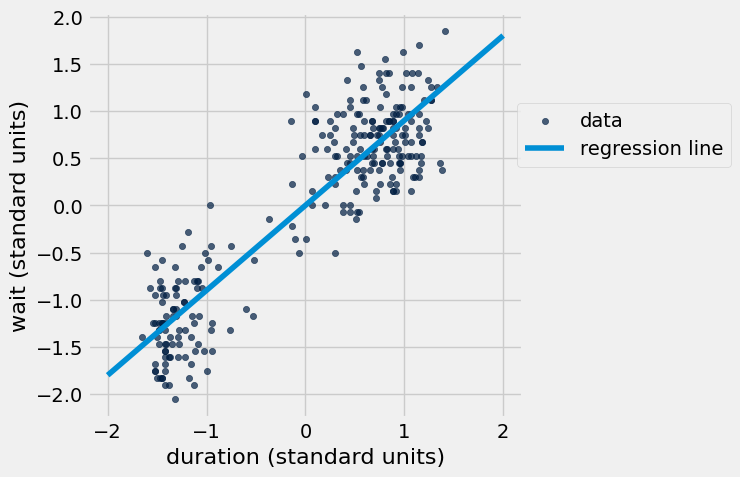

In [14]:
def plot_data_and_line(dataset, x, y, point_0, point_1):
    """Makes a scatter plot of the dataset, along with a line passing through two points."""
    dataset.scatter(x, y, label="data")
    xs, ys = zip(point_0, point_1)
    plots.plot(xs, ys, label="regression line")
    plots.legend(bbox_to_anchor=(1.5,.8))

plot_data_and_line(faithful_standard, 
                   "duration (standard units)", 
                   "wait (standard units)", 
                   [-2, -2*r], 
                   [2, 2*r])

How would you take a point in standard units and convert it back to original units?  We'd have to "stretch" its horizontal position by `duration_std` and its vertical position by `wait_std`. That means the same thing would happen to the slope of the line.

Stretching a line horizontally makes it less steep, so we **divide** the slope by the stretching factor.  Stretching a line vertically makes it more steep, so we **multiply** the slope by the stretching factor.

**Question 2.1.** Calculate the slope of the regression line in original units, and assign it to `slope`.

(If the "stretching" explanation is unintuitive, consult section [15.2](https://www.inferentialthinking.com/chapters/15/2/Regression_Line.html#the-equation-of-the-regression-line) in the textbook.)


In [15]:
slope = r*(wait_std/duration_std)
slope

10.729641395133527

In [16]:
grader.check("q2_1")

q2_1 results: All test cases passed!

We know that the regression line passes through the point `(duration_mean, wait_mean)`. 


**Question 2.2.** Calculate the intercept in original units and assign it to `intercept`. [Section 15.2.5](https://inferentialthinking.com/chapters/15/2/Regression_Line.html#the-regression-line-in-standard-units) may be helpful.

In [17]:
intercept = wait_mean - (slope*duration_mean)
intercept

33.474397022753351

In [18]:
grader.check("q2_2")

q2_2 results: All test cases passed!

# 3. Investigating the Regression Line
The slope and intercept tell you exactly what the regression line looks like.  To predict the waiting time for an eruption, multiply the eruption's duration by `slope` and then add `intercept`.

**Question 3.1.** Compute the predicted waiting time for an eruption that lasts 2 minutes, and for an eruption that lasts 5 minutes.


In [19]:
two_minute_predicted_waiting_time = 2*slope + intercept
five_minute_predicted_waiting_time = 5*slope + intercept

# Here is a helper function to print out your predictions.
# Don't modify the code below.
def print_prediction(duration, predicted_waiting_time):
    print("After an eruption lasting", duration,
          "minutes, we predict you'll wait", predicted_waiting_time,
          "minutes until the next eruption.")

print_prediction(2, two_minute_predicted_waiting_time)
print_prediction(5, five_minute_predicted_waiting_time)

After an eruption lasting 2 minutes, we predict you'll wait 54.933679813 minutes until the next eruption.
After an eruption lasting 5 minutes, we predict you'll wait 87.1226039984 minutes until the next eruption.


In [20]:
grader.check("q3_1")

q3_1 results: All test cases passed!

The next cell plots the line that goes between those two points, which is (a segment of) the regression line.

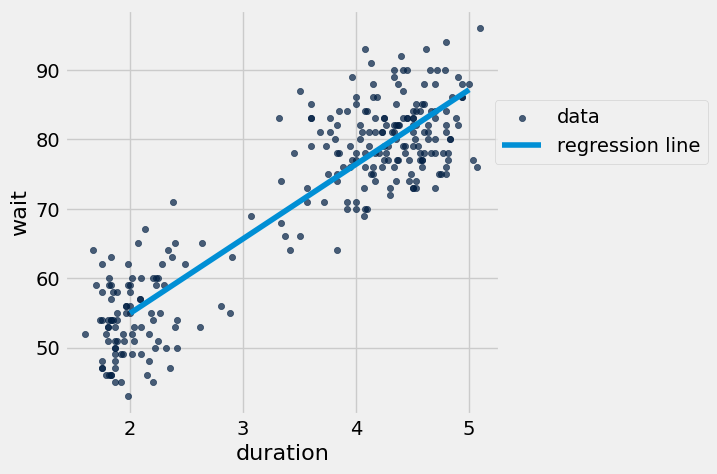

In [21]:
plot_data_and_line(faithful, "duration", "wait", 
                   [2, two_minute_predicted_waiting_time], 
                   [5, five_minute_predicted_waiting_time])

**Question 3.2.** Make predictions for the waiting time after each eruption in the `faithful` table.  (Of course, we know exactly what the waiting times were!  We are doing this so we can see how accurate our predictions are.)  Put these numbers into a column in a new table called `faithful_predictions`.  Its first row should look like this:

|duration|wait|predicted wait|
|-|-|-|
|3.6|79|72.1011|

*Hint:* Your answer can be just one line, though you are not limited to one line.  There is no need for a `for` loop; use array arithmetic instead.
\

In [22]:
faithful_predictions = faithful.with_column("predicted wait", (
    faithful.column("duration")*slope + intercept))
faithful_predictions

duration,wait,predicted wait
3.6,79,72.1011
1.8,54,52.7878
3.333,74,69.2363
2.283,62,57.9702
4.533,85,82.1119
2.883,55,64.408
4.7,88,83.9037
3.6,85,72.1011
1.95,51,54.3972
4.35,85,80.1483


In [23]:
grader.check("q3_2")

q3_2 results: All test cases passed!

**Question 3.3.** How close were we?  Compute the *residual* for each eruption in the dataset.  The residual is the actual waiting time minus the predicted waiting time.  Add the residuals to `faithful_predictions` as a new column called `residual` and name the resulting table `faithful_residuals`.

*Hint:* Again, your code will be much simpler if you don't use a `for` loop.

In [24]:
faithful_residuals = faithful_predictions.with_column("residual", (
    faithful_predictions.column("wait") - faithful_predictions.column(
        "predicted wait")))
faithful_residuals

duration,wait,predicted wait,residual
3.6,79,72.1011,6.89889
1.8,54,52.7878,1.21225
3.333,74,69.2363,4.76371
2.283,62,57.9702,4.02983
4.533,85,82.1119,2.88814
2.883,55,64.408,-9.40795
4.7,88,83.9037,4.09629
3.6,85,72.1011,12.8989
1.95,51,54.3972,-3.3972
4.35,85,80.1483,4.85166


In [25]:
grader.check("q3_3")

q3_3 results: All test cases passed!

Here is a plot of the residuals you computed.  Each point corresponds to one eruption.  It shows how much our prediction over- or under-estimated the waiting time.

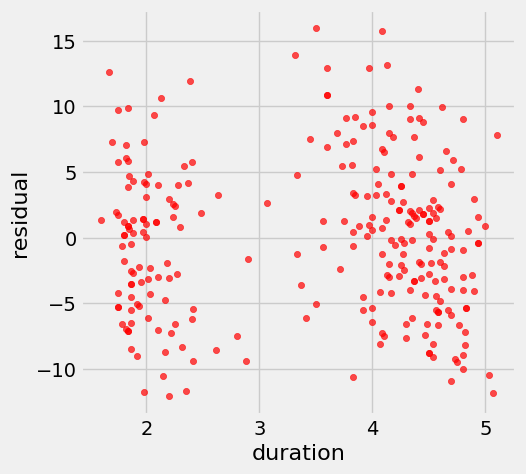

In [26]:
faithful_residuals.scatter("duration", "residual", color="r")

There isn't really a pattern in the residuals, which confirms that it was reasonable to try linear regression.  It's true that there are two separate clouds; the eruption durations seemed to fall into two distinct clusters.  But that's just a pattern in the eruption durations, not a pattern in the relationship between eruption durations and waiting times.

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [27]:
grader.check_all()

q1_1 results: All test cases passed!

q1_4 results: All test cases passed!

q1_6 results: All test cases passed!

q1_7 results: All test cases passed!

q2_1 results: All test cases passed!

q2_2 results: All test cases passed!

q3_1 results: All test cases passed!

q3_2 results: All test cases passed!

q3_3 results: All test cases passed!

Congratulations, you're done with Lab 11! 

Be sure to:
- **run** all the tests 
- **save** your notebook and **download** a pdf version of it,
- **submit** your work to Gradescope.